# Next-patch pretraining of AstroPT, and what its embeddings retrieve

Pretrains `astrospec.models.astropt.AstroPT`
([Smith et al. 2024, arXiv:2405.14930](https://arxiv.org/abs/2405.14930)) on
unlabelled DESI spectra with its native objective, causal next-patch
prediction, then uses the resulting token sequence as a representation and
searches it for nearest neighbours, the same check
`specformer_pretraining.ipynb` runs for SpecFormer's masked-patch objective,
on the same survey `astroclip_similarity_search.ipynb` uses.

Nothing here is supervised. There is currently no public spectra-pretrained
AstroPT checkpoint to load instead (`Smith42/astroPT`'s release is
image-only); this notebook is the only way to get spectra AstroPT weights
today.

Unlike SpecFormer, which positions each patch by its index, AstroPT reads
position from `wavelength` directly, so patches from different pixel grids
are directly comparable, the reason this library patches `wavelength`
alongside `flux` at all. This notebook still uses one survey and its one
fixed grid for simplicity, but nothing about the objective below would
change to mix DESI and SDSS spectra, on their different grids, in the same
batch.

The data path is `utils/desi.py`: a local MultimodalUniverse HDF5 copy if
`ASTROSPEC_DESI_ROOT` is set, otherwise streaming
[`MultimodalUniverse/desi`](https://huggingface.co/datasets/MultimodalUniverse/desi)
from the Hub. Both carry `Z`, so this notebook runs either way. Set `ASTROSPEC_DESI_ROOT` in a `.env` file in this directory (gitignored; see `examples/README.md`) to avoid exporting it by hand; `utils/__init__.py` loads it automatically.

## Install example-only dependencies

Not part of AstroSpec's core install; only needed for this example.

In [1]:
!pip install -q h5py datasets matplotlib tqdm python-dotenv

## Imports

In [2]:
import math

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import astrospec
from astrospec.data import Patchify
from utils import desi

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load spectra

16,000 spectra with their pipeline redshifts, on DESI's native 7,781-pixel
grid, standardized per spectrum. No resampling is needed: every DESI EDR
spectrum in this release already sits on the same grid.

In [3]:
flux, z = desi.load_spectra(16000, redshift=True)
flux = desi.standardize(flux)
wavelength_grid = np.linspace(3600.0, 9824.0, flux.shape[-1]).astype(np.float32)
flux.shape, z.min(), z.max()

((11026, 7781), np.float32(-0.0049771243), np.float32(5.807099))

## Pixels to patches

AstroPT takes raw 32-pixel patches, no per-patch statistics appended (unlike
SpecFormer's 22-number encoding), plus the wavelength of each patch's own
pixels, which its position embedding reads directly. `wavelength_grid` is
the same array for every spectrum here, so it only needs patching once and
broadcasts over the batch.

In [4]:
PATCH_SIZE = 32
patchify = Patchify(patch_size=PATCH_SIZE)

flux_patches, valid = patchify(torch.from_numpy(flux))
wavelength_patches, _ = patchify(torch.from_numpy(wavelength_grid))
flux_patches.shape, wavelength_patches.shape, valid.shape

(torch.Size([11026, 244, 32]), torch.Size([244, 32]), torch.Size([11026, 244]))

## Split and batch

The last 1,000 spectra are held out; they are what the retrieval at the end
searches over, and the model is never trained on them.

In [5]:
n_val = 1000
train_patches, val_patches = flux_patches[:-n_val], flux_patches[-n_val:]
train_valid, val_valid = valid[:-n_val], valid[-n_val:]
val_z = z[-n_val:]

train_loader = DataLoader(
    TensorDataset(train_patches, train_valid), batch_size=64, shuffle=True
)
wavelength_patches = wavelength_patches.to(device).unsqueeze(0)
len(train_patches), len(val_patches)

(10026, 1000)

## The model

The registry defaults match the OmniSpectrum training configuration (8
layers, width 512, no dropout, no biases), verified against its released
checkpoint's shapes in the project's own checkpoint audit; only the
architecture is reused here, not any weights. About 28.5M parameters,
smaller than SpecFormer's 43M, but DESI's native grid patches into 244
positions against SpecFormer's resampled-SDSS 121, so a pass over 15,000
spectra still takes comparably long.

In [6]:
model = astrospec.create_model("astropt", input_dim=PATCH_SIZE).to(device)
sum(p.numel() for p in model.parameters())

28516864

## Pretrain by next-patch prediction

AstroPT's own objective, from its docstring: a Huber loss between
`forward(...)[:, :-1]` and the patches shifted one position, `flux[:, 1:]`,
over pairs where both positions are valid. No input masking is needed.
Causal attention already hides the future from every prediction, so nothing
is gained by copying the input through.

The same warmup-plus-cosine schedule `specformer_pretraining.ipynb` needed
is used here too, with gradient clipping, for the same stability reasons at
this width.

In [7]:
EPOCHS = 20
PEAK_LR = 3e-4
HUBER_DELTA = 1.0
optimizer = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=1e-2)

total_steps = EPOCHS * len(train_loader)
warmup_steps = int(0.1 * total_steps)

def learning_rate(step):
    if step < warmup_steps:
        return PEAK_LR * step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return PEAK_LR * 0.5 * (1 + math.cos(math.pi * progress))

def next_patch_step(batch_patches, batch_valid):
    wavelength = wavelength_patches.expand(len(batch_patches), -1, -1)
    prediction = model(batch_patches, wavelength, valid=batch_valid)

    pair_valid = (batch_valid[:, :-1] & batch_valid[:, 1:]).unsqueeze(-1)
    error = F.huber_loss(
        prediction[:, :-1], batch_patches[:, 1:], delta=HUBER_DELTA, reduction='none'
    )
    return (error * pair_valid).sum() / pair_valid.sum().clamp_min(1)

step = 0
for epoch in (bar := tqdm(range(EPOCHS), desc="pretraining")):
    model.train()
    running = 0.0
    for batch_patches, batch_valid in train_loader:
        for group in optimizer.param_groups:
            group['lr'] = learning_rate(step)
        batch_patches, batch_valid = batch_patches.to(device), batch_valid.to(device)
        optimizer.zero_grad()
        loss = next_patch_step(batch_patches, batch_valid)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(batch_patches)
        step += 1
    bar.set_postfix(huber=f"{running / len(train_patches):.4f}")


pretraining:   0%|          | 0/20 [00:00<?, ?it/s]

pretraining:   0%|          | 0/20 [00:28<?, ?it/s, huber=22.1829]

pretraining:   5%|▌         | 1/20 [00:28<08:58, 28.35s/it, huber=22.1829]

pretraining:   5%|▌         | 1/20 [00:56<08:58, 28.35s/it, huber=21.6123]

pretraining:  10%|█         | 2/20 [00:56<08:30, 28.34s/it, huber=21.6123]

...

pretraining:  90%|█████████ | 18/20 [08:58<00:56, 28.37s/it, huber=20.8181]

pretraining:  95%|█████████▌| 19/20 [08:58<00:28, 28.36s/it, huber=20.8181]

pretraining:  95%|█████████▌| 19/20 [09:26<00:28, 28.36s/it, huber=20.8055]

pretraining: 100%|██████████| 20/20 [09:26<00:00, 28.35s/it, huber=20.8055]

pretraining: 100%|██████████| 20/20 [09:26<00:00, 28.34s/it, huber=20.8055]

## Embed the held-out spectra

`forward_features` returns one causal hidden state per patch. Unlike
SpecFormer's bidirectional tokens, each of these has only seen its own
position and the ones before it, so the last valid one is the summary of the
whole spectrum, not the mean of all of them.

As in `specformer_pretraining.ipynb`, every spectrum's pooled vector carries
the same large common component; centering before the cosine removes it.

In [8]:
@torch.no_grad()
def embed(batch_patches, batch_valid):
    model.eval()
    out = []
    for i in range(0, len(batch_patches), 64):
        x = batch_patches[i : i + 64].to(device)
        v = batch_valid[i : i + 64].to(device)
        wavelength = wavelength_patches.expand(len(x), -1, -1)
        features = model.forward_features(x, wavelength, valid=v)
        last_idx = v.long().sum(dim=1) - 1
        out.append(features[torch.arange(len(x)), last_idx].cpu())
    return torch.cat(out)

pooled = embed(val_patches, val_valid)
embeddings = F.normalize(pooled - pooled.mean(0, keepdim=True), dim=-1)
embeddings.shape

torch.Size([1000, 512])

## Nearest neighbours

Cosine similarity between the embeddings of the held-out spectra, checked
against redshift, which the model never sees, against a random-pair
baseline.

In [9]:
similarity = embeddings @ embeddings.T
similarity.fill_diagonal_(-1)
best = similarity.max(-1)
neighbour, neighbour_score = best.indices.numpy(), best.values.numpy()

rng = np.random.default_rng(0)
shuffled = rng.permutation(len(val_z))
random_score = (embeddings * embeddings[shuffled]).sum(-1).numpy()

print(f"{'':>17}  {'cosine':>8}  {'median |dz|':>12}  {'|dz| < 0.01':>12}")
for name, score, delta in [
    ("nearest neighbour", neighbour_score, np.abs(val_z - val_z[neighbour])),
    ("random pair", random_score, np.abs(val_z - val_z[shuffled])),
]:
    print(
        f"{name:>17}  {np.median(score):8.3f}  {np.median(delta):12.4f}"
        f"  {(delta < 0.01).mean():11.1%}"
    )

                     cosine   median |dz|   |dz| < 0.01
nearest neighbour     0.809        0.1264        20.7%
      random pair     0.028        0.5186         5.2%


## A query and its three nearest neighbours

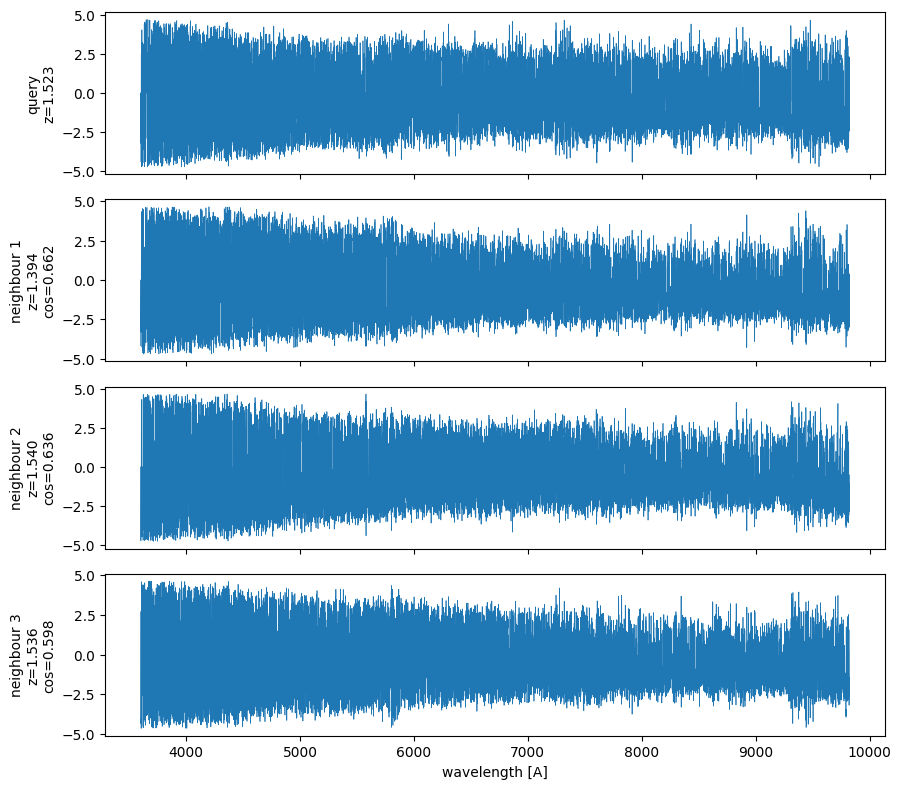

In [10]:
import matplotlib.pyplot as plt

query = int(np.argmax(val_z > 0.3))
top = similarity[query].topk(3)
panels = [(query, "query", None)] + [
    (int(i), f"neighbour {k + 1}", float(s))
    for k, (i, s) in enumerate(zip(top.indices, top.values))
]

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, (i, title, score) in zip(axes, panels):
    ax.plot(wavelength_grid, flux[-n_val:][i], lw=0.5)
    label = f"{title}\nz={val_z[i]:.3f}"
    ax.set_ylabel(label if score is None else f"{label}\ncos={score:.3f}")
axes[-1].set_xlabel("wavelength [A]")
fig.tight_layout()

## Notes

Small on purpose: 16,000 spectra and 20 epochs, with last-token pooling as
the read-out. `astropt_classification_on_sdss.ipynb` uses this same
architecture, trained fully supervised instead, since no pretrained spectra
checkpoint exists to fine-tune from. Attaching a supervised head to the
representation pretrained here, and comparing the two, is the natural next
step this notebook does not do.

Reading the two rows: as with SpecFormer, a nearest neighbour is both more
similar in embedding space and closer in redshift than a random pair. This
is not a redshift estimator; it shows the next-patch objective and the
wavelength-based position embedding both working end to end.